# Figure 2 Analysis Notebook

This notebook runs the full Figure 2 workflow.

Sections:
- Import packages and define utility functions
- Section a: Multilamellar vesicles (MLVs)
- Section b: Vero cells with MBCD treatment
- Section c: BAL analysis

## Import packages and define utility functions
This cell imports all required analysis and plotting libraries, then defines reusable utility functions used across Sections A, B, and C.

It includes helpers to:

- Locate and list `.fcs` files from one or more folders.
- Load spectral signals from FCS files and compute phasor features.
- Normalize harmonic input and build phasor DataFrames for single or multiple harmonics.
- Extract robust phasor centers (median-based) for control/reference files.
- Parse condition labels (MLVs, VERO, BAL) and sort/group them consistently.
- Build condition-specific colormaps for contour and density plots.
- Apply shared axis styling and standardized figure save/show/close behavior.
- Plot normalized fraction histograms with variability (mean ± SD).
- Define reference masks for MLV endpoints and helpers for component-polygon drawing.

These functions centralize preprocessing, visualization, and condition handling so the analysis cells remain compact and consistent.

In [1]:
# Core imports for IO, phasor computation, and plotting
import os
import re

import fcsparser
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from phasorpy.component import phasor_component_fit
from phasorpy.phasor import phasor_center, phasor_from_signal
from phasorpy.plot import PhasorPlot


# Generic filesystem and plotting helpers.
def list_fcs_files(data_paths):
    """Return sorted .fcs files found across input folders.

    Args:
        data_paths: Iterable of folder paths to scan.

    Returns:
        list[str]: Sorted absolute/relative paths to .fcs files.
    """
    return sorted(
        [
            os.path.join(folder_path, filename)
            for folder_path in data_paths
            if os.path.exists(folder_path)
            for filename in os.listdir(folder_path)
            if filename.endswith(".fcs")
        ]
    )


def save_show_close(fig, output_path):
    """Apply layout, save a figure, display it, and close it.

    Args:
        fig: Matplotlib figure object.
        output_path: Destination path for the saved image.
    """
    plt.tight_layout()
    fig.savefig(output_path, dpi=600, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def style_axes(ax, tick_size, label_size):
    """Apply shared axis styling used across figures.

    Args:
        ax: Matplotlib axes to style.
        tick_size: Font size for tick labels.
        label_size: Font size for axis labels.
    """
    ax.set_facecolor("white")
    ax.tick_params(axis="both", which="major", labelsize=tick_size)
    ax.set_xlabel(ax.get_xlabel(), fontsize=label_size)
    ax.set_ylabel(ax.get_ylabel(), fontsize=label_size)
    ax.set_title("")


# Condition parsing and color helpers for lipid experiments.
def sort_lipid_condition(filename):
    """Build sorting key for lipid labels and cholesterol percentage.

    Args:
        filename: Condition label or filename containing lipid tokens.

    Returns:
        tuple[int, int]: (lipid priority, cholesterol percentage).
    """
    match = re.search(r"(\d+)%", filename)
    percentage = int(match.group(1)) if match else 0

    if "DOPC DPPC" in filename:
        lipid_priority = 3
    elif "DOPC" in filename:
        lipid_priority = 1
    elif "DPPC" in filename:
        lipid_priority = 2
    else:
        lipid_priority = 4

    return lipid_priority, percentage


def get_group_from_condition(condition):
    """Map a condition string to a lipid group label.

    Args:
        condition: Condition text.

    Returns:
        str: One of DOPC, DPPC, DOPC DPPC, or Other.
    """
    if "DOPC DPPC" in condition:
        return "DOPC DPPC"
    if "DOPC" in condition:
        return "DOPC"
    if "DPPC" in condition:
        return "DPPC"
    return "Other"


def get_cholesterol_percentage(condition):
    """Extract cholesterol percentage from a condition string.

    Args:
        condition: Condition text that may include '<n>%'.

    Returns:
        int: Parsed percentage, or 0 when absent.
    """
    match = re.search(r"(\d+)%", condition)
    return int(match.group(1)) if match else 0


def get_condition_colormap(condition):
    """Create a condition-specific colormap and representative color.

    Args:
        condition: Condition text used to infer group and percentage.

    Returns:
        tuple: (matplotlib colormap, sampled RGBA color).
    """
    group = get_group_from_condition(condition)
    chol_pct = get_cholesterol_percentage(condition)

    percentage_to_position = {
        0: 0.45,
        10: 0.55,
        15: 0.62,
        25: 0.70,
        30: 0.78,
        40: 0.85,
        50: 0.95,
    }
    cmap_position = percentage_to_position.get(chol_pct, 0.5)

    base_cmaps = {
        "DOPC": "Blues",
        "DPPC": "Reds",
        "DOPC DPPC": "Greens",
        "Other": "Greys",
    }
    base_cmap = plt.get_cmap(base_cmaps.get(group, "Greys"))

    sampled_color = base_cmap(cmap_position)
    span = np.linspace(cmap_position - 0.1, cmap_position + 0.1, 256)
    span = np.clip(span, 0.0, 1.0)
    colors_list = [base_cmap(v) for v in span]
    custom_cmap = mcolors.LinearSegmentedColormap.from_list(
        f"{group}_{chol_pct}", colors_list
    )
    return custom_cmap, sampled_color


# Phasor extraction and dataframe assembly utilities.
def extract_spectral_signal(file_path):
    """Load spectral channels from an FCS file as a NumPy array.

    Args:
        file_path: Path to the input .fcs file.

    Returns:
        numpy.ndarray: Spectral matrix ordered by channel index.
    """
    _, data = fcsparser.parse(file_path, reformat_meta=True)
    spectral_cols = sorted(
        [col for col in data.columns if "V" in col],
        key=lambda x: int(x.split("-")[0][1:]),
    )
    return data[spectral_cols].to_numpy()


def normalize_harmonics(harmonics):
    """Normalize harmonic input into a list.

    Args:
        harmonics: None, int, or iterable of harmonics.

    Returns:
        list[int]: Harmonics list (default [1]).
    """
    if harmonics is None:
        return [1]
    if isinstance(harmonics, int):
        return [harmonics]
    return harmonics


def get_phasor_dataframe_from_fcs(
    fcs_file_list, condition_extractor=None, harmonics=None
):
    """Compute phasor features from FCS files and return a tidy DataFrame.

    Args:
        fcs_file_list: Sequence of .fcs file paths.
        condition_extractor: Optional callable to derive condition labels.
        harmonics: None, int, or list of harmonics to compute.

    Returns:
        pandas.DataFrame: Per-event phasor data with condition and source labels.
    """
    harmonics = normalize_harmonics(harmonics)

    mean_data = []
    real_data = {h: [] for h in harmonics}
    imag_data = {h: [] for h in harmonics}
    condition_labels = []
    source_files = []

    for file_path in fcs_file_list:
        filename = os.path.splitext(os.path.basename(file_path))[0]
        condition = condition_extractor(filename) if condition_extractor else filename
        fluorescence_signal = extract_spectral_signal(file_path)

        if len(harmonics) == 1:
            mean, real, imag = phasor_from_signal(
                fluorescence_signal, harmonic=harmonics[0]
            )
            real = np.atleast_2d(real)
            imag = np.atleast_2d(imag)
        else:
            mean, real, imag = phasor_from_signal(
                fluorescence_signal, harmonic=harmonics
            )

        mean_flat = mean.flatten()
        real_flat = [r.flatten() for r in real]
        imag_flat = [i.flatten() for i in imag]

        # Keep only finite rows across all harmonics to avoid invalid fit inputs.
        valid_mask = np.isfinite(mean_flat)
        for harmonic_index in range(len(harmonics)):
            valid_mask &= np.isfinite(real_flat[harmonic_index]) & np.isfinite(
                imag_flat[harmonic_index]
            )

        mean_clean = mean_flat[valid_mask]
        if len(mean_clean) == 0:
            continue

        mean_data.extend(mean_clean)
        condition_labels.extend([condition] * len(mean_clean))
        source_files.extend([filename] * len(mean_clean))
        for harmonic_index, harmonic in enumerate(harmonics):
            real_data[harmonic].extend(real_flat[harmonic_index][valid_mask])
            imag_data[harmonic].extend(imag_flat[harmonic_index][valid_mask])

    result = {
        "Mean": mean_data,
        "Condition": condition_labels,
        "SourceFile": source_files,
    }

    if len(harmonics) == 1:
        result["Real"] = real_data[harmonics[0]]
        result["Imag"] = imag_data[harmonics[0]]
    else:
        for harmonic in harmonics:
            result[f"Real_h{harmonic}"] = real_data[harmonic]
            result[f"Imag_h{harmonic}"] = imag_data[harmonic]

    return pd.DataFrame(result)


def get_phasor_centers_from_fcs(file_path, harmonics=None):
    """Compute median phasor centers for a control/reference FCS file.

    Args:
        file_path: Path to input .fcs file.
        harmonics: None, int, or list of harmonics.

    Returns:
        tuple: Arrays of center real and imaginary coordinates.
    """
    harmonics = normalize_harmonics(harmonics)
    signal = extract_spectral_signal(file_path)
    phasor = phasor_from_signal(signal, harmonic=harmonics)
    _, centers_real, centers_imag = phasor_center(*phasor, method="median")
    return centers_real, centers_imag


# Fraction plotting and component geometry helpers.
def plot_fraction_histograms(
    dataframe, columns_to_plot, output_folder, conditions=None, condition_colors=None
):
    """Plot normalized per-condition fraction histograms with mean and SD band.

    Args:
        dataframe: Input DataFrame containing fractions and condition labels.
        columns_to_plot: Dict mapping column name to (xmin, xmax).
        output_folder: Directory where plots are written.
        conditions: Optional ordered iterable of conditions to render.
        condition_colors: Optional mapping condition -> matplotlib color.
    """
    if conditions is None:
        conditions = dataframe["Condition"].unique()

    os.makedirs(output_folder, exist_ok=True)

    for column, (x_min, x_max) in columns_to_plot.items():
        fig, ax = plt.subplots(figsize=(7, 7))
        ax.set_box_aspect(1)
        bins = np.linspace(x_min, x_max, 100)
        bin_centers = (bins[:-1] + bins[1:]) / 2

        for condition in conditions:
            condition_mask = dataframe["Condition"] == condition
            selected_columns = [column] + (
                ["SourceFile"] if "SourceFile" in dataframe.columns else []
            )
            condition_df = dataframe.loc[condition_mask, selected_columns].dropna()

            if len(condition_df) == 0:
                continue

            file_ids = (
                condition_df["SourceFile"].unique()
                if "SourceFile" in condition_df.columns
                else ["all_data"]
            )
            per_file_hists = []

            for file_id in file_ids:
                if file_id == "all_data":
                    file_data = condition_df[column].to_numpy()
                else:
                    file_data = condition_df.loc[
                        condition_df["SourceFile"] == file_id, column
                    ].to_numpy()

                if len(file_data) == 0:
                    continue

                hist, _ = np.histogram(file_data, bins=bins, density=False)
                max_val = np.max(hist)
                if max_val > 0:
                    per_file_hists.append(hist / max_val)

            if len(per_file_hists) == 0:
                continue

            hist_array = np.vstack(per_file_hists)
            mean_hist = np.mean(hist_array, axis=0)
            std_hist = np.std(hist_array, axis=0)

            color = (
                condition_colors.get(condition)
                if condition_colors is not None
                else None
            )
            line = ax.plot(
                bin_centers, mean_hist, label=condition, linewidth=2, color=color
            )
            line_color = line[0].get_color()

            lower = np.clip(mean_hist - std_hist, 0, None)
            upper = np.clip(mean_hist + std_hist, 0, 1.2)
            ax.fill_between(bin_centers, lower, upper, alpha=0.25, color=line_color)

            center_of_mass = np.sum(bin_centers * mean_hist) / np.sum(mean_hist)
            if np.sum(mean_hist) > 0 and not np.isnan(center_of_mass):
                ax.axvline(
                    center_of_mass,
                    color=line_color,
                    linestyle="--",
                    linewidth=2.5,
                    alpha=0.7,
                    label=f"{condition} CM: {center_of_mass:.3f}",
                )

        xlabel_text = column.replace("_", " ")
        if xlabel_text.startswith("Fraction "):
            fraction_part = xlabel_text[len("Fraction ") :]
            xlabel_text = (
                "L$_{o}$ fraction"
                if fraction_part == "Lo"
                else f"{fraction_part} fraction"
            )

        ax.set_xlabel(xlabel_text, fontsize=20)
        ax.set_ylabel("Number of pixels + SD (normalized)", fontsize=20)
        ax.set_xlim(x_min, x_max)
        ax.legend(fontsize=14, loc="upper right")
        ax.tick_params(axis="both", which="major", labelsize=18)

        save_show_close(fig, os.path.join(output_folder, f"{column}_distribution.png"))


def build_mlvs_reference_masks(mlvs_dataframe):
    """Build boolean masks identifying DOPC and DPPC endpoint references.

    Args:
        mlvs_dataframe: MLV phasor DataFrame with a Condition column.

    Returns:
        tuple[pandas.Series, pandas.Series]: (dopc_mask, dppc_mask).
    """
    dopc_mask = (
        mlvs_dataframe["Condition"].str.contains("DOPC")
        & mlvs_dataframe["Condition"].str.contains("0%")
        & ~mlvs_dataframe["Condition"].str.contains("DPPC")
    )
    dppc_mask = (
        mlvs_dataframe["Condition"].str.contains("DPPC")
        & mlvs_dataframe["Condition"].str.contains("33%")
        & ~mlvs_dataframe["Condition"].str.contains("DOPC")
    )
    return dopc_mask, dppc_mask


def draw_component_polygon(ax, components_real, components_imag, style):
    """Draw component connectors, closing the polygon for three components.

    Args:
        ax: Matplotlib axes where lines are drawn.
        components_real: Component real coordinates.
        components_imag: Component imaginary coordinates.
        style: Keyword arguments passed to ax.plot.
    """
    if len(components_real) == 3:
        real_closed = np.append(components_real, components_real[0])
        imag_closed = np.append(components_imag, components_imag[0])
        ax.plot(real_closed, imag_closed, **style)
        return
    ax.plot(components_real, components_imag, **style)


# Dataset-specific condition mappers and density palettes.
def extract_vero_condition(filename):
    """Map VERO filename text to analysis condition labels.

    Args:
        filename: Filename without extension.

    Returns:
        str: Background, MβCD, or Control.
    """
    if "Background" in filename:
        return "Background"
    if "BMCD" in filename:
        return "MβCD"
    return "Control"


def sort_vero_condition(condition):
    """Return sorting priority for VERO conditions.

    Args:
        condition: Condition label.

    Returns:
        int: Priority index used for ordering plots.
    """
    if condition == "MβCD":
        return 0
    if condition == "Control":
        return 1
    return 2


def extract_bal_condition(filename):
    """Map BAL filenames into LPS or Control groups.

    Args:
        filename: Filename without extension.

    Returns:
        str: LPS when token is present, otherwise Control.
    """
    return "LPS" if "LPS" in filename else "Control"


def get_condition_density_cmap(condition, condition_colors):
    """Build a white-to-dark density colormap from a base condition color.

    Args:
        condition: Condition key for color lookup.
        condition_colors: Dict mapping condition -> base hex color.

    Returns:
        matplotlib.colors.LinearSegmentedColormap: Density colormap.
    """
    base_hex = condition_colors.get(condition, "#808080")
    base_rgb = np.array(mcolors.to_rgb(base_hex))
    light_rgb = 1 - (1 - base_rgb) * 0.25
    dark_rgb = base_rgb * 0.55

    return mcolors.LinearSegmentedColormap.from_list(
        f"{condition}_density",
        [(1.0, 1.0, 1.0), tuple(light_rgb), tuple(base_rgb), tuple(dark_rgb)],
        N=256,
    )

## Section a: Multilamellar Vesicles (MLV) analysis of LAURDAN fluorescence 

### MLV Input Loading and Global Contours
Load MLV `.fcs` files, compute harmonic phasor data, and generate the merged phasor contour plot with a zoom rectangle.

### Key parameters
- `data_paths`: input folders for MLV datasets.
- `output_folder_a`: where figures are saved.
- `harmonics` in `get_phasor_dataframe_from_fcs` (currently `[1, 2]`).
- `zoom_xlim_a`, `zoom_ylim_a`: zoom window limits.
- Contour style arguments (`linewidths`, `levels`, `alpha`) for merged contours.
- Figure size and axis text sizes in `plt.subplots` and `style_axes`.

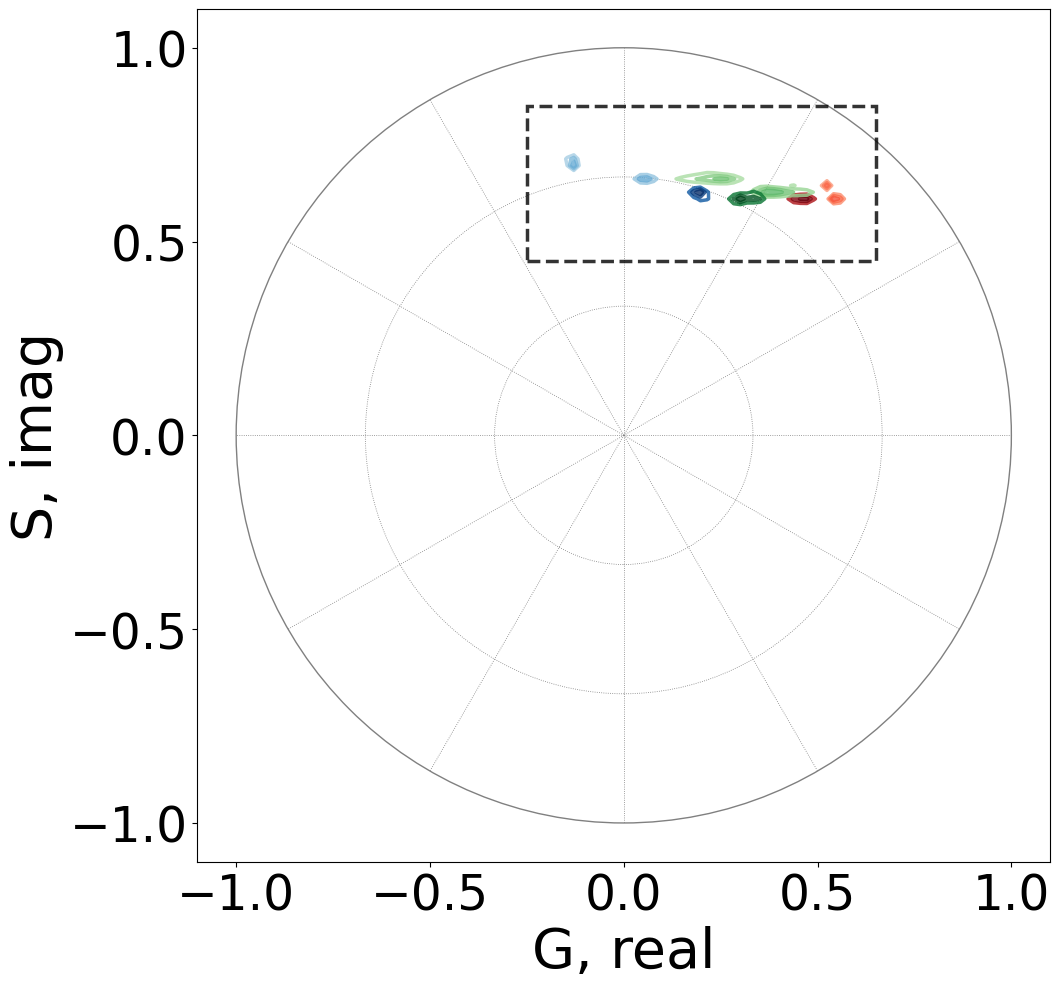

In [ ]:
# Load and merge all MLV files before plotting condition contours.
data_paths = [
    "../data/SFC/MLVs/Pre-gated/MLVs 1",
    "../data/SFC/MLVs/Pre-gated/MLVs 2",
]

output_folder_a = os.path.join("Figure_2", "Figure_2a")
os.makedirs(output_folder_a, exist_ok=True)

fcs_files_a = list_fcs_files(data_paths)
mlvs_phasor_dataframe = get_phasor_dataframe_from_fcs(fcs_files_a, harmonics=[1, 2])
unique_conditions_a = sorted(
    mlvs_phasor_dataframe["Condition"].unique(), key=sort_lipid_condition
)

zoom_xlim_a = (-0.25, 0.65)
zoom_ylim_a = (0.45, 0.85)

fig, ax = plt.subplots(figsize=(12, 10), facecolor="white")
style_axes(ax, tick_size=35, label_size=40)
phasor_plot = PhasorPlot(allquadrants=True, title="", ax=ax)

for condition in unique_conditions_a:
    condition_data = mlvs_phasor_dataframe[
        mlvs_phasor_dataframe["Condition"] == condition
    ]

    if len(condition_data) <= 10:
        continue

    real = condition_data["Real_h1"].values
    imag = condition_data["Imag_h1"].values
    custom_cmap, _ = get_condition_colormap(condition)
    phasor_plot.contour(
        real, imag, cmap=custom_cmap, linewidths=2.5, levels=3, alpha=0.8
    )

# Draw the rectangle that defines the region shown in the dedicated zoom panel.
zoom_rect = Rectangle(
    (zoom_xlim_a[0], zoom_ylim_a[0]),
    zoom_xlim_a[1] - zoom_xlim_a[0],
    zoom_ylim_a[1] - zoom_ylim_a[0],
    linewidth=2.5,
    edgecolor="black",
    facecolor="none",
    linestyle="--",
    alpha=0.8,
    zorder=10,
)
ax.add_patch(zoom_rect)

handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

save_show_close(
    fig,
    os.path.join(output_folder_a, "phasor_contour_all_conditions_merged.png"),
)

### Zoomed MLV View and Endpoint Masks
Create the zoomed MLV phasor contour view and compute reference masks for DOPC and DPPC endpoint populations.

### Key parameters
- `zoom_xlim_a`, `zoom_ylim_a`: displayed phasor range in the zoom panel.
- Contour appearance (`linewidths`, `levels`, `alpha`).
- Tick spacing in `ax.set_xticks` and `ax.set_yticks`.
- Output filename for the zoomed figure.
- The logical rules in `build_mlvs_reference_masks` if endpoint definitions need to change.

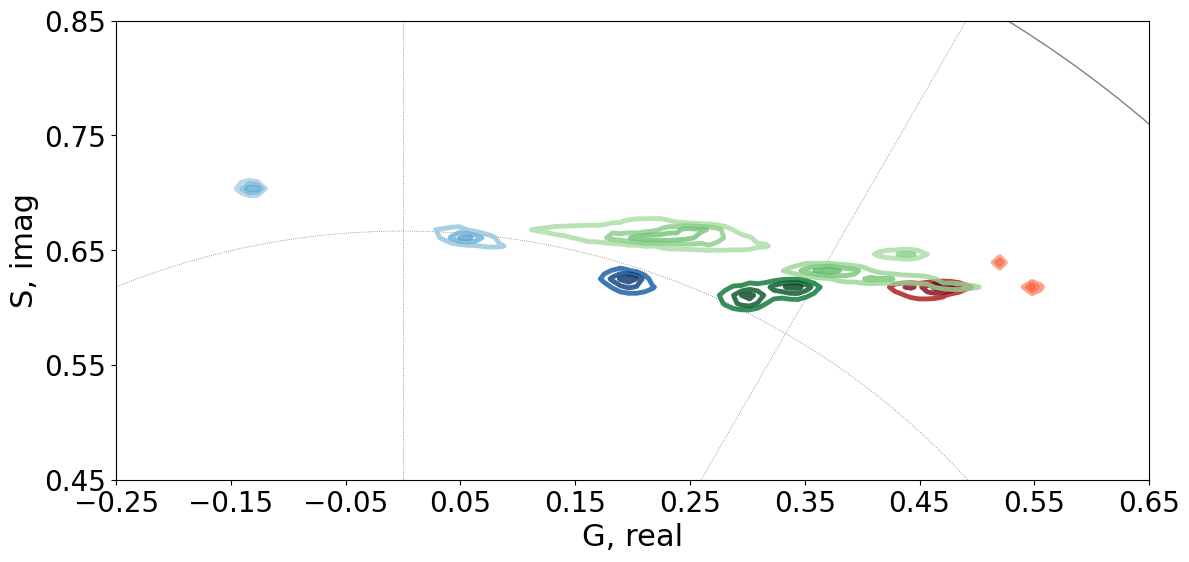

In [3]:
# Zoomed phasor plot section
fig, ax = plt.subplots(figsize=(12, 10), facecolor="white")
style_axes(ax, tick_size=20, label_size=22)
phasor_plot_zoom = PhasorPlot(
    allquadrants=True, title="", ax=ax, xlim=zoom_xlim_a, ylim=zoom_ylim_a
)

# Reuse the same condition loop, but restrict rendering to the zoomed window.
for condition in unique_conditions_a:
    condition_data = mlvs_phasor_dataframe[
        mlvs_phasor_dataframe["Condition"] == condition
    ]
    if len(condition_data) <= 10:
        continue

    real = condition_data["Real_h1"].values
    imag = condition_data["Imag_h1"].values
    custom_cmap, _ = get_condition_colormap(condition)
    phasor_plot_zoom.contour(
        real, imag, cmap=custom_cmap, linewidths=3.5, levels=3, alpha=0.8
    )

ax.set_xticks(np.arange(zoom_xlim_a[0], zoom_xlim_a[1] + 0.01, 0.1))
ax.set_yticks(np.arange(zoom_ylim_a[0], zoom_ylim_a[1] + 0.01, 0.1))

save_show_close(
    fig,
    os.path.join(output_folder_a, "phasor_contour_all_conditions_merged_zoom.png"),
)

# Keep endpoint masks for downstream component fitting in sections B and C.
dopc_mask, dppc_mask = build_mlvs_reference_masks(mlvs_phasor_dataframe)

## Section b: Vero cells LAURDAN fluorescence analysis with MβCD treatment

Run Vero analysis, estimate component fractions, and export phasor/fraction plots.

### Vero Data Loading and Labeling
Initialize Section b by loading VERO `.fcs` files, assigning conditions (`Control`, `MβCD`, `Background`), and computing first harmonic phasor data.

### Key parameters
- `data_paths_b`: input folder(s) for Vero experiments.
- `output_folder_b`: destination for Section B outputs.
- `condition_extractor` logic (`extract_vero_condition`) to redefine sample grouping.
- `harmonics` setting (currently `[1]`) if multi-harmonic analysis is needed.

In [ ]:
# Section b: Vero cells with MBCD treatment
data_paths_b = [
    "../data/SFC/Vero cells/Pre-gated/Vero cells 1",
    "../data/SFC/Vero cells/Pre-gated/Vero cells 2",
    "../data/SFC/Vero cells/Pre-gated/Vero cells 3",
    ]
output_folder_b = os.path.join("Figure_2", "Figure_2b")
os.makedirs(output_folder_b, exist_ok=True)

fcs_files_b = list_fcs_files(data_paths_b)
# Build the Vero phasor table with condition labels inferred from filenames.
vero_phasor_dataframe = get_phasor_dataframe_from_fcs(
    fcs_files_b,
    condition_extractor=extract_vero_condition,
    harmonics=[1],
)

### Vero Component Analysis
Estimate phasor component centers for Vero analysis (Ld, Lo, background) and run component fitting to obtain per-event fractions.

### Key parameters
- Which statistics define centers (currently medians from selected masks).
- Composition/order of `components_real_b` and `components_imag_b`.
- Input subsets used for center estimation (`dopc_mask`, `dppc_mask`, background mask).
- Output fraction column names if you want alternate naming conventions.

In [5]:
# Compute component centers and perform component analysis
bg_mask = vero_phasor_dataframe["Condition"] == "Background"
background_real_median = vero_phasor_dataframe.loc[bg_mask, "Real"].median()
background_imag_median = vero_phasor_dataframe.loc[bg_mask, "Imag"].median()

# Use MLV-derived Ld/Lo anchors plus the measured background center.
components_real_b = np.array(
    [
        mlvs_phasor_dataframe.loc[dopc_mask, "Real_h1"].median(),
        mlvs_phasor_dataframe.loc[dppc_mask, "Real_h1"].median(),
        background_real_median,
    ]
)
components_imag_b = np.array(
    [
        mlvs_phasor_dataframe.loc[dopc_mask, "Imag_h1"].median(),
        mlvs_phasor_dataframe.loc[dppc_mask, "Imag_h1"].median(),
        background_imag_median,
    ]
)

fractions_b = phasor_component_fit(
    vero_phasor_dataframe["Mean"].to_numpy(),
    vero_phasor_dataframe["Real"].to_numpy(),
    vero_phasor_dataframe["Imag"].to_numpy(),
    components_real_b,
    components_imag_b,
)
vero_phasor_dataframe[["Fraction_Ld", "Fraction_Lo", "Fraction_Background"]] = (
    fractions_b.T
)

### Vero Overview Phasor Plot
Generate the main VERO phasor plot with condition contours, median markers, component polygon, labels, and the zoom guide rectangle.

### Key parameters
- `condition_color_mapping_b`: contour colormap and marker colors by condition.
- Condition ordering rule (`sort_vero_condition`).
- Minimum data threshold (`len(condition_data) <= 10`).
- Label text, positions, and font sizes for component names.
- Zoom rectangle limits (`zoom_xlim_b`, `zoom_ylim_b`) and style.
- Figure size and axis typography.

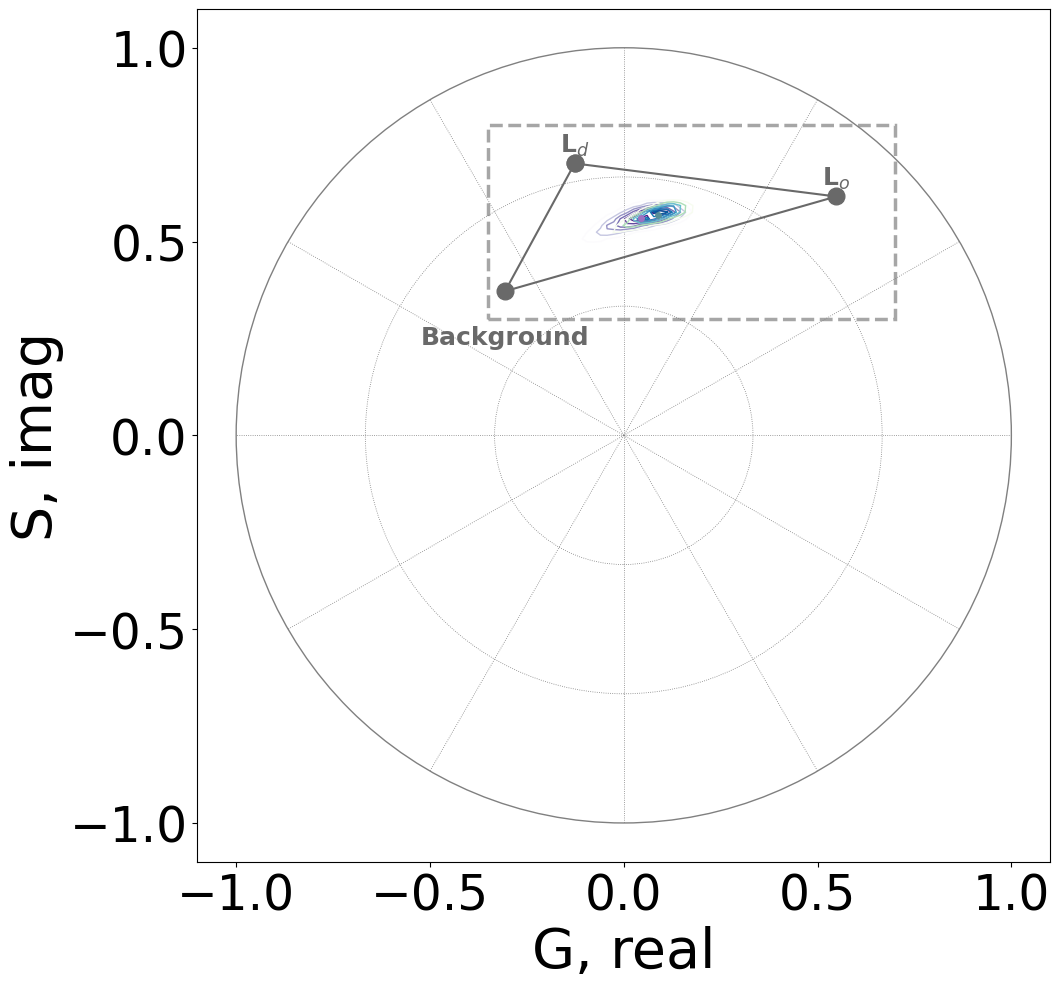

In [6]:
# Plot phasor contours and component centers
unique_conditions_b = sorted(
    vero_phasor_dataframe["Condition"].unique(), key=sort_vero_condition
)

condition_color_mapping_b = {
    "MβCD": {"cmap": "Purples", "color": "#9D71C3"},
    "Control": {"cmap": "GnBu", "color": "#588E98"},
    "Background": {"cmap": "Greys", "color": "gray"},
}

fig, ax = plt.subplots(figsize=(12, 10), facecolor="white")
style_axes(ax, tick_size=35, label_size=40)
phasor_plot = PhasorPlot(allquadrants=True, title="", ax=ax, pad=0.1)

# Plot only biological conditions; background is represented as a component anchor.
for condition in unique_conditions_b:
    if condition == "Background":
        continue

    condition_data = vero_phasor_dataframe[
        vero_phasor_dataframe["Condition"] == condition
    ]
    if len(condition_data) <= 10:
        continue

    real = condition_data["Real"].values
    imag = condition_data["Imag"].values
    colors_map = condition_color_mapping_b.get(
        condition, condition_color_mapping_b["Background"]
    )
    phasor_plot.contour(real, imag, cmap=colors_map["cmap"], linewidths=1)
    phasor_plot.plot(
        np.nanmedian(real),
        np.nanmedian(imag),
        color=colors_map["color"],
        marker="o",
        markersize=4,
        label=condition,
        zorder=5,
    )

component_style = {
    "linestyle": "-",
    "marker": "o",
    "markersize": 12,
    "color": "dimgray",
}
draw_component_polygon(ax, components_real_b, components_imag_b, component_style)

ax.text(
    components_real_b[0],
    components_imag_b[0] + 0.015,
    "L$_{d}$",
    color="dimgray",
    fontsize=18,
    ha="center",
    va="bottom",
    fontweight="bold",
)
ax.text(
    components_real_b[1],
    components_imag_b[1] + 0.015,
    "L$_{o}$",
    color="dimgray",
    fontsize=18,
    ha="center",
    va="bottom",
    fontweight="bold",
)
ax.text(
    components_real_b[-1],
    components_imag_b[-1] - 0.15,
    "Background",
    color="dimgray",
    fontsize=18,
    ha="center",
    va="bottom",
    fontweight="bold",
)

zoom_xlim_b = (-0.35, 0.7)
zoom_ylim_b = (0.3, 0.8)
rect = Rectangle(
    (zoom_xlim_b[0], zoom_ylim_b[0]),
    zoom_xlim_b[1] - zoom_xlim_b[0],
    zoom_ylim_b[1] - zoom_ylim_b[0],
    linewidth=2.5,
    edgecolor="gray",
    facecolor="none",
    linestyle="--",
    alpha=0.7,
)
ax.add_patch(rect)

save_show_close(fig, os.path.join(output_folder_b, "vero_phasor.png"))

### Vero Zoom Panel and Annotations
Create the zoomed Vero phasor panel, add condition center labels, draw component references, and save the detailed zoom figure.

### Key parameters
- Tick spacing and zoom extents (`zoom_xlim_b`, `zoom_ylim_b`).
- Label placement logic (`conditions_top_label`, per-condition offsets).
- Marker sizes and contour style in the zoomed panel.
- Component annotation offsets and text formatting.
- Whether to show/hide legend entries.

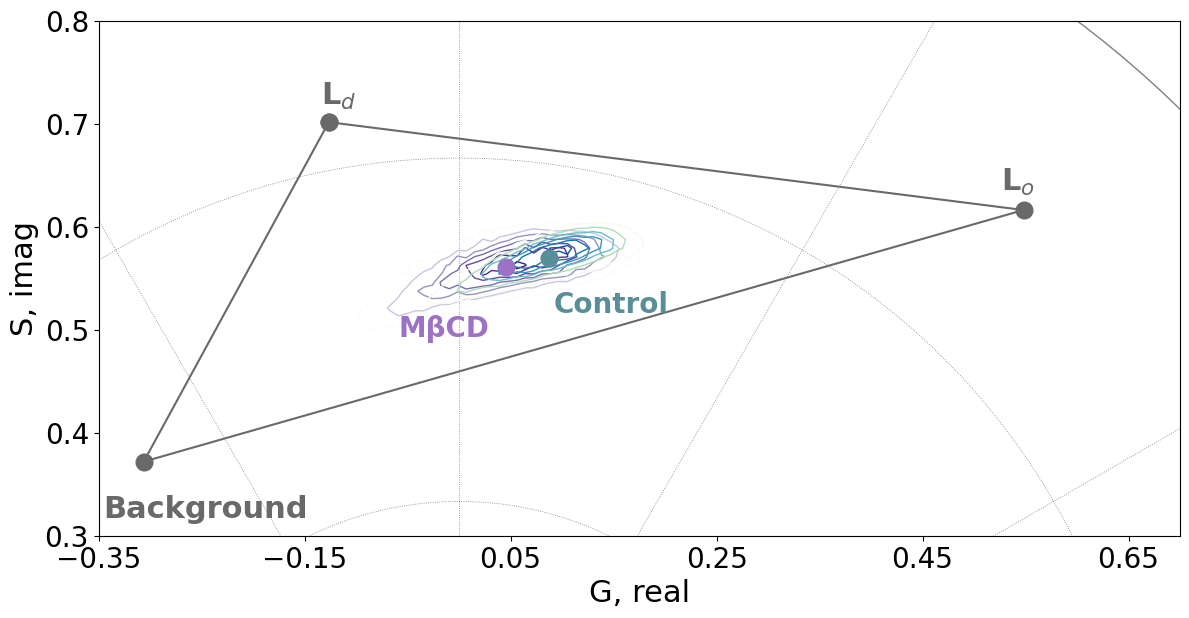

In [7]:
# Plot zoomed phasor section with component centers and labels
fig, ax = plt.subplots(figsize=(12, 10), facecolor="white")
style_axes(ax, tick_size=20, label_size=22)
phasor_plot_zoom = PhasorPlot(
    allquadrants=True, title="", ax=ax, xlim=zoom_xlim_b, ylim=zoom_ylim_b
)
ax.set_xticks(np.arange(zoom_xlim_b[0], zoom_xlim_b[1] + 0.01, 0.2))
ax.set_yticks(np.arange(zoom_ylim_b[0], zoom_ylim_b[1] + 0.01, 0.1))

conditions_top_label = {"MβCD"}
for condition in unique_conditions_b:
    if condition == "Background":
        continue

    condition_data = vero_phasor_dataframe[
        vero_phasor_dataframe["Condition"] == condition
    ]
    if len(condition_data) <= 10:
        continue

    real = condition_data["Real"].values
    imag = condition_data["Imag"].values
    colors_map = condition_color_mapping_b.get(
        condition, condition_color_mapping_b["Background"]
    )
    phasor_plot_zoom.contour(real, imag, cmap=colors_map["cmap"], linewidths=1)

    center_real = np.nanmedian(real)
    center_imag = np.nanmedian(imag)
    phasor_plot_zoom.plot(
        center_real,
        center_imag,
        color=colors_map["color"],
        marker="o",
        markersize=12,
        label=condition,
        zorder=5,
    )

    # Offset labels manually so they do not overlap with contour peaks.
    if condition in conditions_top_label:
        label_x, label_y = center_real - 0.06, center_imag - 0.06
    else:
        label_x, label_y = center_real + 0.06, center_imag - 0.045

    ax.text(
        label_x,
        label_y,
        condition,
        color=colors_map["color"],
        fontsize=20,
        ha="center",
        va="center",
        fontweight="bold",
    )

draw_component_polygon(ax, components_real_b, components_imag_b, component_style)
ax.text(
    components_real_b[0] + 0.01,
    components_imag_b[0] + 0.01,
    "L$_{d}$",
    color="dimgray",
    fontsize=22,
    ha="center",
    va="bottom",
    fontweight="bold",
)
ax.text(
    components_real_b[1] - 0.005,
    components_imag_b[1] + 0.012,
    "L$_{o}$",
    color="dimgray",
    fontsize=22,
    ha="center",
    va="bottom",
    fontweight="bold",
)
ax.text(
    components_real_b[2] + 0.06,
    components_imag_b[2] - 0.06,
    "Background",
    color="dimgray",
    fontsize=22,
    ha="center",
    va="bottom",
    fontweight="bold",
)

legend = ax.legend()
if legend is not None:
    legend.set_visible(False)

save_show_close(fig, os.path.join(output_folder_b, "vero_phasor_zoom.png"))

### Vero Lo Fraction Distribution Histogram
Plot normalized histogram distributions of `Fraction_Lo` for Vero conditions (excluding background), including mean profile and variability.

### Key parameters
- Histogram targets (currently `{\"Fraction_Lo\": (0, 1)}`).
- Condition subset for plotting (include/exclude `Background`).
- `condition_colors` mapping for line/fill colors.
- Bin count and normalization behavior inside `plot_fraction_histograms`.
- Output folder and filename pattern.

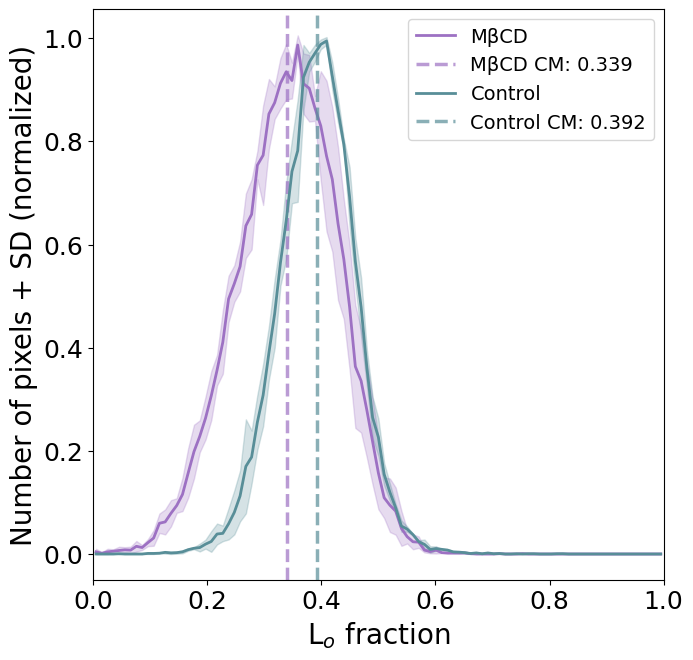

In [8]:
# Plot normalized fraction histograms for Vero conditions.
plot_fraction_histograms(
    vero_phasor_dataframe,
    {"Fraction_Lo": (0, 1)},
    output_folder_b,
    conditions=[c for c in unique_conditions_b if c != "Background"],
    condition_colors={
        condition: values["color"]
        for condition, values in condition_color_mapping_b.items()
    },
)

## Section c: Bronchoalveolar Lavage (BAL) leukocyte LAURDAN fluorescence analysis after LPS exposure.

Run BAL analysis with multi-component fitting and generate per-condition harmonic plots.

### BAL Inputs and Harmonic Configuration
Initialize Section c by locating BAL input/control files, selecting harmonics, and building the BAL phasor DataFrame with condition labels.

### Key parameters
- `data_path_c` and `control_path_c`: dataset and control directories.
- Specific control filenames (`cd45_path`, `cd11c_path`, `af_path`).
- `output_folder_c`: destination for Section C plots.
- `harmonics_c` (currently `[1, 2]`) for single vs multi-harmonic fitting.
- Condition parsing logic in `extract_bal_condition`.

In [ ]:
# Section c: BAL analysis
data_path_c = "../data/SFC/BAL/Pre-gated"
control_path_c = os.path.join(data_path_c, "Single Labels and autofluorescence")

# Control files define component anchors for immune markers and autofluorescence.
cd45_path = os.path.join(control_path_c, "CD45 - Control.fcs")
cd11c_path = os.path.join(
    control_path_c, "CD11c - Control.fcs"
)
af_path = os.path.join(control_path_c, "Autofluorescence - Control.fcs")

output_folder_c = os.path.join("Figure_2", "Figure_2c")
os.makedirs(output_folder_c, exist_ok=True)

fcs_files_c = sorted([f for f in os.listdir(data_path_c) if f.endswith(".fcs")])
full_fcs_paths_c = [os.path.join(data_path_c, filename) for filename in fcs_files_c]
harmonics_c = [1, 2]

bal_phasor_dataframe = get_phasor_dataframe_from_fcs(
    full_fcs_paths_c,
    condition_extractor=extract_bal_condition,
    harmonics=harmonics_c,
)

### BAL Multi-Component Model Construction
Compute multi-harmonic component centers (MLV + controls), perform BAL component fitting, and append all fraction columns to the BAL DataFrame.

### Key parameters
- Manual component anchor values (currently fixed CD45 points in `components_real_c`/`components_imag_c`).
- Component set and order (`component_labels_c`) used in fitting.
- Label display mapping (`component_label_display_c`) and `label_offsets_c` for annotations.
- Harmonics used for fitting (`harmonics_c`).
- Fraction column naming convention (`Fraction_<label>`).

In [10]:
# Compute component centers for MLV references and controls, then perform component fitting
ld_c1_real = mlvs_phasor_dataframe.loc[dopc_mask, "Real_h1"].median()
ld_c1_imag = mlvs_phasor_dataframe.loc[dopc_mask, "Imag_h1"].median()
ld_c2_real = mlvs_phasor_dataframe.loc[dopc_mask, "Real_h2"].median()
ld_c2_imag = mlvs_phasor_dataframe.loc[dopc_mask, "Imag_h2"].median()

lo_c1_real = mlvs_phasor_dataframe.loc[dppc_mask, "Real_h1"].median()
lo_c1_imag = mlvs_phasor_dataframe.loc[dppc_mask, "Imag_h1"].median()
lo_c2_real = mlvs_phasor_dataframe.loc[dppc_mask, "Real_h2"].median()
lo_c2_imag = mlvs_phasor_dataframe.loc[dppc_mask, "Imag_h2"].median()

cd45_creal, cd45_cimag = get_phasor_centers_from_fcs(cd45_path, harmonics=harmonics_c)
cd11c_creal, cd11c_cimag = get_phasor_centers_from_fcs(
    cd11c_path, harmonics=harmonics_c
)
af_creal, af_cimag = get_phasor_centers_from_fcs(af_path, harmonics=harmonics_c)

# Harmonic-specific component coordinates expected by phasor_component_fit.
components_real_c = [
    [ld_c1_real, lo_c1_real, 0.732, cd11c_creal[0], af_creal[0]],
    [ld_c2_real, lo_c2_real, 0.100, cd11c_creal[1], af_creal[1]],
]
components_imag_c = [
    [ld_c1_imag, lo_c1_imag, -0.595, cd11c_cimag[0], af_cimag[0]],
    [ld_c2_imag, lo_c2_imag, -0.750, cd11c_cimag[1], af_cimag[1]],
]

component_labels_c = ["Ld", "Lo", "CD45", "CD11c", "AF"]
component_label_display_c = {"Ld": "L$_{d}$", "Lo": "L$_{o}$"}
label_offsets_c = {
    1: {
        "Ld": (0, 0.07),
        "Lo": (0, 0.07),
        "CD45": (-0.15, -0.1),
        "CD11c": (-0.15, -0.05),
        "AF": (-0.15, 0),
    },
    2: {
        "Ld": (-0.1, -0.01),
        "Lo": (0, 0.05),
        "CD45": (0, -0.1),
        "CD11c": (-0.15, 0.04),
        "AF": (-0.08, -0.08),
    },
}

real_array_c = bal_phasor_dataframe[[f"Real_h{h}" for h in harmonics_c]].to_numpy().T
imag_array_c = bal_phasor_dataframe[[f"Imag_h{h}" for h in harmonics_c]].to_numpy().T

fractions_c = phasor_component_fit(
    bal_phasor_dataframe["Mean"].to_numpy(),
    real_array_c,
    imag_array_c,
    components_real_c,
    components_imag_c,
)
for component_index, label in enumerate(component_labels_c):
    bal_phasor_dataframe[f"Fraction_{label}"] = fractions_c[component_index]

### BAL Condition-Wise Phasor Density Maps
Generate BAL phasor density plots for each condition (`LPS`, `Control`) and harmonic, overlay component geometry, annotate labels, and export images.

### Key parameters
- `color_map_c`: condition colors used for density colormaps.
- Condition iteration order/list (`[\"LPS\", \"Control\"]`).
- Harmonics and corresponding plotting loop (`harmonics_c`).
- `bins` in `hist2d` and plot styling (`markersize`, line styles).
- Text offsets in `label_offsets_c` and annotation font settings.
- Figure size and output naming format (`bal_<condition>_phasor_h<h>.png`).

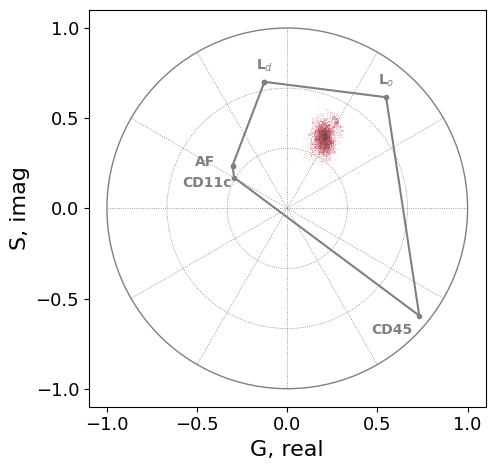

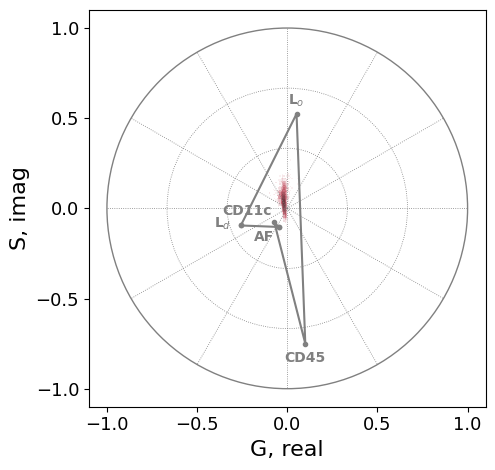

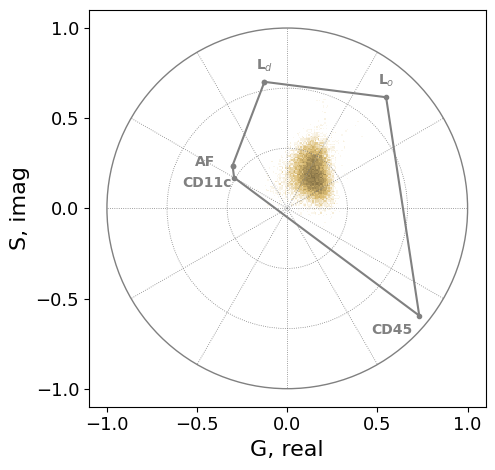

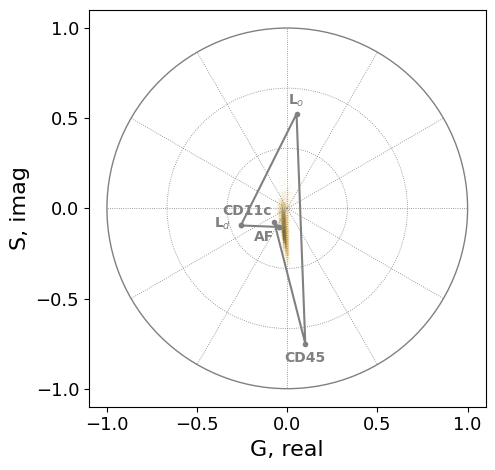

In [11]:
# Phasor plots for BAL conditions with component centers and labels
color_map_c = {"Control": "#DBBC73", "LPS": "#C86573"}

# Render one map per condition and per harmonic to keep component geometry readable.
for condition in ["LPS", "Control"]:
    condition_data = bal_phasor_dataframe[
        bal_phasor_dataframe["Condition"] == condition
    ]

    for harmonic_index, harmonic in enumerate(harmonics_c):
        merged_real = condition_data[f"Real_h{harmonic}"].to_numpy()
        merged_imag = condition_data[f"Imag_h{harmonic}"].to_numpy()

        if len(merged_real) == 0:
            print(f"No data for condition: {condition}")
            continue

        fig, ax = plt.subplots(facecolor="white")
        style_axes(ax, tick_size=13, label_size=16)
        phasor_plot = PhasorPlot(allquadrants=True, title="", ax=ax)

        cmap = get_condition_density_cmap(condition, color_map_c)
        phasor_plot.hist2d(merged_real, merged_imag, bins=300, cmap=cmap)

        phasor_plot.plot(
            components_real_c[harmonic_index],
            components_imag_c[harmonic_index],
            linestyle="-",
            marker="o",
            color="gray",
            markersize=3,
        )
        phasor_plot.plot(
            [
                components_real_c[harmonic_index][-1],
                components_real_c[harmonic_index][0],
            ],
            [
                components_imag_c[harmonic_index][-1],
                components_imag_c[harmonic_index][0],
            ],
            linestyle="-",
            marker="o",
            color="gray",
            markersize=3,
        )

        for component_position, label in enumerate(component_labels_c):
            offset_x, offset_y = label_offsets_c[harmonic][label]
            display_label = component_label_display_c.get(label, label)
            ax.text(
                components_real_c[harmonic_index][component_position] + offset_x,
                components_imag_c[harmonic_index][component_position] + offset_y,
                display_label,
                fontsize=10,
                color="gray",
                ha="center",
                fontweight="bold",
            )

        save_show_close(
            fig,
            os.path.join(output_folder_c, f"bal_{condition}_phasor_h{harmonic}.png"),
        )

### BAL Fraction Comparison Histogram
Plot normalized `Fraction_Lo` distributions for BAL `Control` vs `LPS` and save the comparative histogram output.

### Key parameters
- Histogram variable(s) and range (currently `{\"Fraction_Lo\": (0, 1.0)}`).
- Condition order/list for comparison (`[\"Control\", \"LPS\"]`).
- `condition_colors` values used for line and shading colors.
- Internal histogram binning and variability display in `plot_fraction_histograms`.

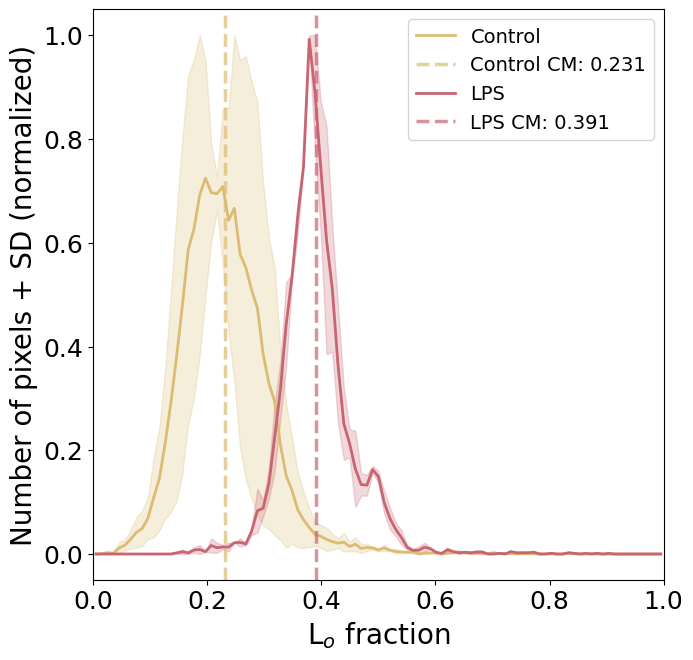

In [12]:
# Compare Lo-fraction distributions between Control and LPS BAL samples.
plot_fraction_histograms(
    bal_phasor_dataframe,
    {"Fraction_Lo": (0, 1.0)},
    output_folder_c,
    conditions=["Control", "LPS"],
    condition_colors=color_map_c,
)